# Telco Customer Churn Prediction

## Project Goal
Predict which customers are likely to churn and identify the key business drivers behind churn.

## Approach
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building and Comparison
- Evaluation using Recall, F1, and AUC

## Business Objective
The goal is not only to predict churn, but to understand customer behavior and support retention strategies.

## 1. Import libraries



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

from IPython.display import display

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load the dataset


In [2]:
df = pd.read_csv("Telco-Customer-Churn_Dataset.csv", sep=";")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## 3. Data Overview



In [3]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

## 4. Data cleaning
- Converted `TotalCharges` to numeric format
- Mapped target variable `Churn` into binary (0/1)
- Removed `customerID` as it does not provide predictive value


In [4]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [7]:
df = df.drop(columns=["customerID"])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio_pct": (df.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

missing_summary

,missing_count,missing_ratio_pct
TotalCharges,11,0.160
gender,0,0.000
SeniorCitizen,0,0.000
MonthlyCharges,0,0.000
PaymentMethod,0,0.000
PaperlessBilling,0,0.000
Contract,0,0.000
StreamingMovies,0,0.000
StreamingTV,0,0.000
TechSupport,0,0.000


## 5. Train-Test Split

Data was split into training and test sets to evaluate model performance properly and avoid data leakage .

In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train ratio:")
display(y_train.value_counts(normalize=True).rename("ratio").round(3))

X_train shape: (5634, 19)
X_test shape : (1409, 19)
y_train ratio:


Churn
0   0.735
1   0.265
Name: ratio, dtype: float64

## 6. Data Preparation for Modeling

`TotalCharges` is filled with the **training median** and the same value is used for the test set.

In [11]:
train_totalcharges_median = X_train["TotalCharges"].median()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(train_totalcharges_median)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(train_totalcharges_median)

print("Train median used for TotalCharges:", round(train_totalcharges_median, 3))
print("Train missing after fill:", X_train["TotalCharges"].isnull().sum())
print("Test missing after fill :", X_test["TotalCharges"].isnull().sum())

Train median used for TotalCharges: 1398.125
Train missing after fill: 0
Test missing after fill : 0


## 7. Feature Engineering

Create new features to better capture customer behavior, engagement, and lifecycle.

In [12]:
def add_features(dataframe):
    df_ = dataframe.copy()

    df_["NEW_IsNewCustomer"] = (df_["tenure"] <= 12).astype(int)
    df_["NEW_LongTermCustomer"] = (df_["tenure"] >= 48).astype(int)

    service_cols = [
        "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
    ]
    
    def has_service(x):
        x = str(x).strip().lower()
        return 1 if x in ["yes", "dsl", "fiber optic"] else 0

    df_["NEW_TotalServices"] = df_[service_cols].applymap(has_service).sum(axis=1)
    df_["NEW_HasInternet"] = df_["InternetService"].apply(lambda x: 0 if str(x).strip().lower() == "no" else 1)
    df_["NEW_HasStreaming"] = (
        (df_["StreamingTV"].astype(str).str.strip().str.lower() == "yes") |
        (df_["StreamingMovies"].astype(str).str.strip().str.lower() == "yes")
    ).astype(int)

    df_["NEW_IsMonthToMonth"] = (df_["Contract"].astype(str).str.strip() == "Month-to-month").astype(int)
    df_["NEW_IsElectronicCheck"] = (df_["PaymentMethod"].astype(str).str.strip() == "Electronic check").astype(int)
    df_["NEW_AutoPayment"] = df_["PaymentMethod"].astype(str).str.contains("automatic", case=False, na=False).astype(int)

    df_["NEW_AvgMonthlySpend"] = df_["TotalCharges"] / (df_["tenure"] + 1)
    df_["NEW_ChargesPerService"] = df_["MonthlyCharges"] / (df_["NEW_TotalServices"] + 1)

    return df_

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

print("X_train_fe shape:", X_train_fe.shape)
print("X_test_fe shape :", X_test_fe.shape)
X_train_fe.head()

X_train_fe shape: (5634, 29)
X_test_fe shape : (1409, 29)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NEW_IsNewCustomer,NEW_LongTermCustomer,NEW_TotalServices,NEW_HasInternet,NEW_HasStreaming,NEW_IsMonthToMonth,NEW_IsElectronicCheck,NEW_AutoPayment,NEW_AvgMonthlySpend,NEW_ChargesPerService
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.200,1701.650,0,0,4,1,1,1,1,0,47.268,9.840
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.100,1151.550,0,0,3,1,0,1,0,0,71.972,18.775
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.550,590.350,0,0,4,1,0,0,0,0,42.168,8.110
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.500,1905.700,0,0,6,1,1,0,0,1,70.581,10.500
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.550,44.550,1,0,2,1,0,1,1,0,22.275,14.850


## Feature Engineering Insight

Engineered features significantly enhanced the model’s ability to capture customer behavior. In particular, tenure, contract type, and service usage emerged as key drivers in identifying high-risk customers.

## 8. Exploratory Data Analysis (EDA)

Analyze customer behavior and identify key patterns and drivers related to churn.

Churn
0   0.735
1   0.265
Name: ratio, dtype: float64

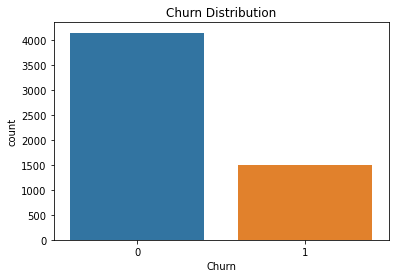

In [13]:
train_eda = X_train_fe.copy()
train_eda["Churn"] = y_train.values

display(train_eda["Churn"].value_counts(normalize=True).rename("ratio").round(3))

plt.figure(figsize=(6, 4))
sns.countplot(data=train_eda, x="Churn")
plt.title("Churn Distribution")
plt.show()

## Churn Distribution Insight

- Around 25–30% of customers churn, which is typical for telecom, as switching is relatively easy.

 This makes recall important, since missing churners has direct business cost.

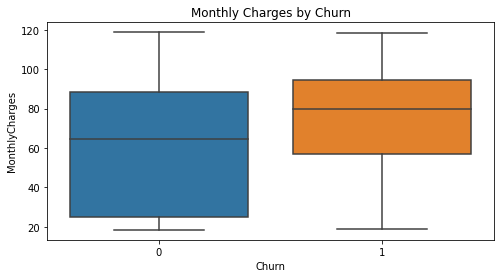

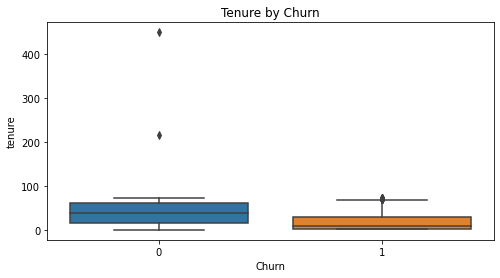

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_eda, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=train_eda, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

## Customer Behavior Insights

- Customers with short tenure churn more, likely because they are not yet engaged or committed.
- Customers with higher monthly charges churn more, likely due to price sensitivity.

 Early-stage and high-paying customers are the main risk groups.

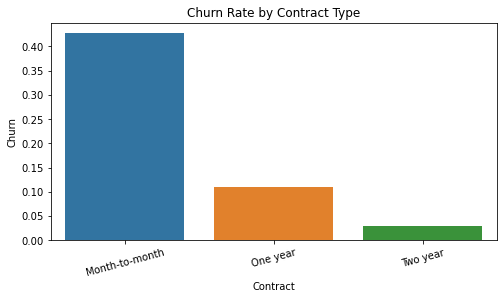

In [15]:
contract_churn = (
    train_eda.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=contract_churn, x="Contract", y="Churn")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=15)
plt.show()



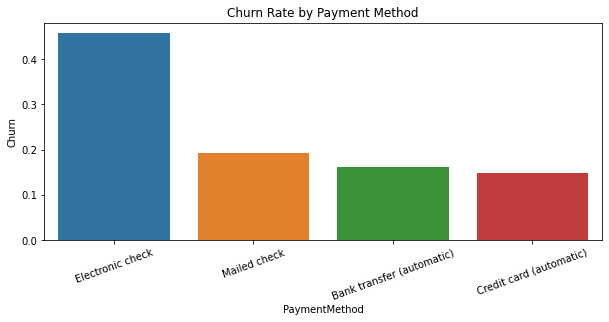

In [16]:
payment_churn = (
    train_eda.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=payment_churn, x="PaymentMethod", y="Churn")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=20)
plt.show()


## Contract Type Insight

- Month-to-month customers churn more, because they have no long-term commitment.
- Long-term contracts reduce churn by increasing switching cost.

 Commitment level is a key driver of retention.

## 9. Feature Encoding

Categorical features are converted into numerical representations to make them suitable for machine learning models.

In [17]:
X_train_encoded = pd.get_dummies(X_train_fe, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_fe, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape :", X_test_encoded.shape)

Encoded train shape: (5634, 40)
Encoded test shape : (1409, 40)


## 10. Model Evaluation

Compare model performance using key classification metrics to identify the most effective model for churn prediction.

In [18]:
all_results = []
trained_models = {}

def evaluate_model(model_name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)

    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Recall", "Precision", "F1", "AUC"],
        "Value": [
            accuracy_score(y_test_data, y_pred),
            recall_score(y_test_data, y_pred),
            precision_score(y_test_data, y_pred),
            f1_score(y_test_data, y_pred),
            roc_auc_score(y_test_data, y_prob)
        ]
    })
    metrics_df["Value"] = metrics_df["Value"].round(3)

    print(f"===== {model_name} =====")
    display(metrics_df)

    all_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test_data, y_pred), 3),
        "Recall": round(recall_score(y_test_data, y_pred), 3),
        "Precision": round(precision_score(y_test_data, y_pred), 3),
        "F1": round(f1_score(y_test_data, y_pred), 3),
        "AUC": round(roc_auc_score(y_test_data, y_prob), 3)
    })

    trained_models[model_name] = model

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_test_data, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    RocCurveDisplay.from_predictions(y_test_data, y_prob)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    return model

## 10.1.  Model 1 — Random Forest
This is the baseline Random Forest model.

===== Random Forest =====


,Metric,Value
0,Accuracy,0.776
1,Recall,0.719
2,Precision,0.562
3,F1,0.631
4,AUC,0.839


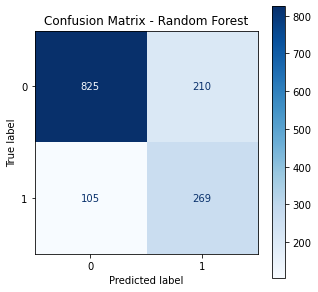

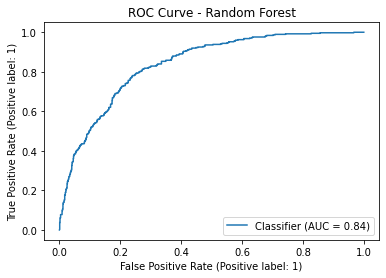

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model = evaluate_model(
    model_name="Random Forest",
    model=rf_model,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)

## 10.2. Model 2 — HPO Random Forest
RandomizedSearchCV is used to search for a stronger Random Forest configuration.

In [20]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [5, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None]
}

rf_base_for_search = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

Best RF params:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth
0,400,10,2,sqrt,8


===== HPO Random Forest =====


,Metric,Value
0,Accuracy,0.765
1,Recall,0.773
2,Precision,0.540
3,F1,0.636
4,AUC,0.842


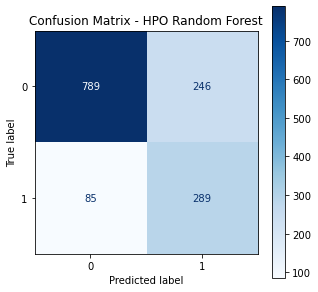

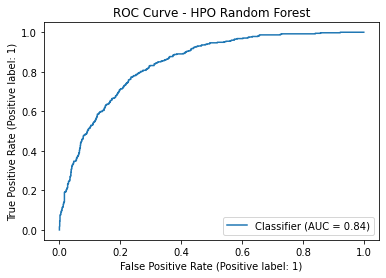

In [21]:
rf_search = RandomizedSearchCV(
    estimator=rf_base_for_search,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train_encoded, y_train)

print("Best RF params:")
display(pd.DataFrame([rf_search.best_params_]))

hpo_rf_model = rf_search.best_estimator_

hpo_rf_model = evaluate_model(
    model_name="HPO Random Forest",
    model=hpo_rf_model,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)

## 10.3. Model 3 — Baseline CatBoost
CatBoost is useful for churn problems and often performs well with mixed feature types.

===== Baseline CatBoost =====


,Metric,Value
0,Accuracy,0.796
1,Recall,0.527
2,Precision,0.640
3,F1,0.578
4,AUC,0.844


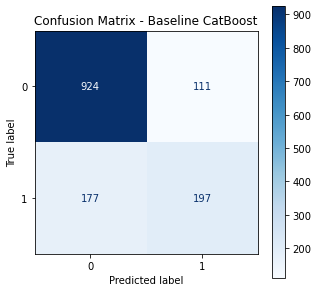

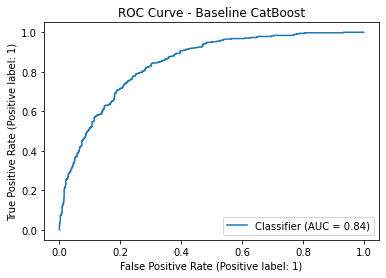

In [22]:
catboost_base = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=0
)

catboost_base = evaluate_model(
    model_name="Baseline CatBoost",
    model=catboost_base,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)
    

## 10.4. Model 4 — Improved CatBoost
This version uses a stronger manual configuration to improve performance.

===== Improved CatBoost =====


,Metric,Value
0,Accuracy,0.799
1,Recall,0.521
2,Precision,0.652
3,F1,0.579
4,AUC,0.845


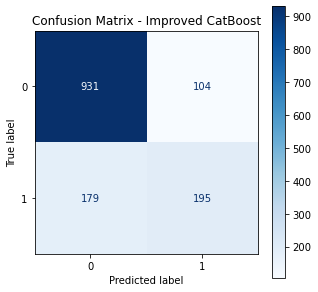

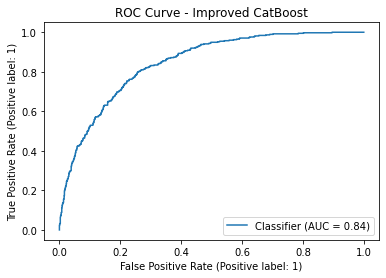

In [23]:
catboost_improved = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=0
)

catboost_improved = evaluate_model(
    model_name="Improved CatBoost",
    model=catboost_improved,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)


## 10.5. Model 5 — CART
This is the baseline decision tree model.

===== CART =====


,Metric,Value
0,Accuracy,0.748
1,Recall,0.759
2,Precision,0.517
3,F1,0.615
4,AUC,0.834


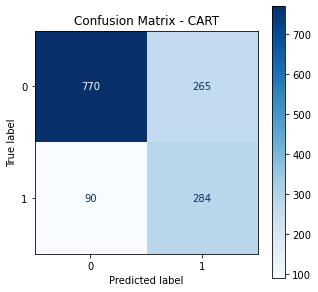

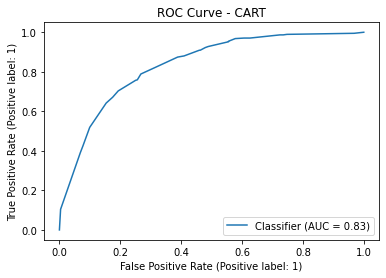

In [24]:
cart_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

cart_model = evaluate_model(
    model_name="CART",
    model=cart_model,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)

## 10.6. Model 6 — HPO CART
RandomizedSearchCV is used to find a stronger decision tree configuration.

In [25]:
cart_param_dist = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4, 8, 10, 15],
    "criterion": ["gini", "entropy", "log_loss"]
}

cart_base_for_search = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

Best CART params:


,min_samples_split,min_samples_leaf,max_depth,criterion
0,10,8,5,gini


===== HPO CART =====


,Metric,Value
0,Accuracy,0.748
1,Recall,0.759
2,Precision,0.517
3,F1,0.615
4,AUC,0.834


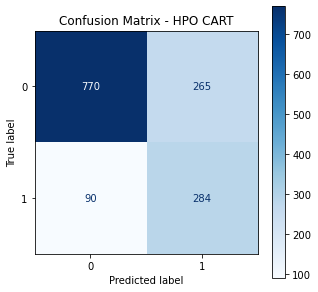

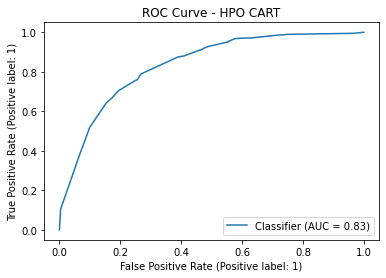

In [26]:
cart_search = RandomizedSearchCV(
    estimator=cart_base_for_search,
    param_distributions=cart_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cart_search.fit(X_train_encoded, y_train)

print("Best CART params:")
display(pd.DataFrame([cart_search.best_params_]))

hpo_cart_model = cart_search.best_estimator_

hpo_cart_model = evaluate_model(
    model_name="HPO CART",
    model=hpo_cart_model,
    X_train_data=X_train_encoded,
    y_train_data=y_train,
    X_test_data=X_test_encoded,
    y_test_data=y_test
)

## 11. Final comparison table
This table shows all tested model variations together.

In [27]:
results_df = pd.DataFrame(all_results).sort_values(by="AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Recall,Precision,F1,AUC
0,Improved CatBoost,0.799,0.521,0.652,0.579,0.845
1,Baseline CatBoost,0.796,0.527,0.640,0.578,0.844
2,HPO Random Forest,0.765,0.773,0.540,0.636,0.842
3,Random Forest,0.776,0.719,0.562,0.631,0.839
4,CART,0.748,0.759,0.517,0.615,0.834
5,HPO CART,0.748,0.759,0.517,0.615,0.834


## Model Performance Insights

- CatBoost has the best AUC, meaning it ranks customers well by churn risk.
- Random Forest has better recall and F1, meaning it identifies more churn customers.

 This difference exists because models optimize different patterns in the data.

In [28]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Best model based on AUC:", best_model_name)

Best model based on AUC: Improved CatBoost


## 12. Cross-validation for the best model
AUC is re-checked with 5-fold stratified cross-validation on the training set.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_auc_scores = cross_val_score(
    estimator=best_model,
    X=X_train_encoded,
    y=y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_results_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "AUC": np.round(cv_auc_scores, 3)
})

display(cv_results_df)
print("Mean CV AUC:", round(cv_auc_scores.mean(), 3))
print("Std CV AUC :", round(cv_auc_scores.std(), 3))

,Fold,AUC
0,1,0.841
1,2,0.830
2,3,0.843
3,4,0.859
4,5,0.858


Mean CV AUC: 0.846
Std CV AUC : 0.011


## 13. Feature importance
If the best model supports feature importance, the top drivers are displayed below.

,Feature,Importance
1,tenure,12.714
13,NEW_ChargesPerService,10.298
9,NEW_IsMonthToMonth,9.802
3,TotalCharges,8.870
12,NEW_AvgMonthlySpend,8.012
2,MonthlyCharges,7.007
35,Contract_Two year,5.442
20,InternetService_Fiber optic,4.122
36,PaperlessBilling_Yes,3.088
38,PaymentMethod_Electronic check,2.952


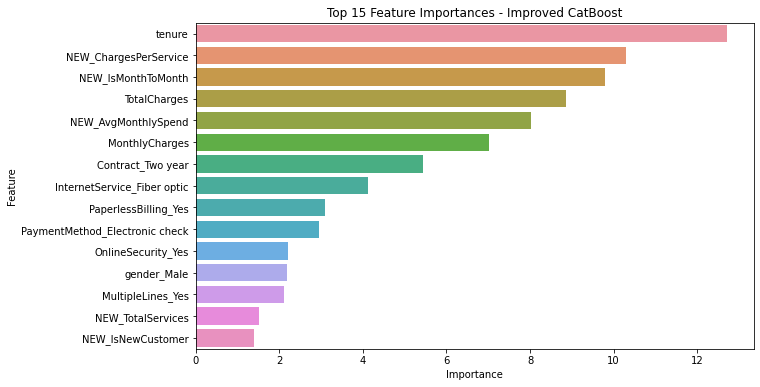

In [30]:
if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X_train_encoded.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    top_features = feature_importance_df.head(15)

    display(top_features)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, x="Importance", y="Feature")
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.show()
else:
    print(f"{best_model_name} does not provide feature_importances_.")

## Model Performance Insights

- Improved CatBoost achieved the highest AUC (0.845), indicating the strongest ability to rank customers by churn risk.
- HPO Random Forest achieved the highest Recall (0.773) and F1-score (0.636), making it more effective at identifying churners.
- Decision Tree (CART) models showed lower performance, suggesting limited ability to capture complex customer behavior patterns.

This highlights a trade-off: CatBoost is better for ranking risk, while Random Forest is better for detecting churners.

## Key Drivers of Churn

- Feature importance analysis shows that tenure is the most influential factor, indicating that customer lifecycle plays a critical role in churn.
- Features such as NEW_ChargesPerService and MonthlyCharges highlight strong price sensitivity among customers.
- Contract-related features (NEW_IsMonthToMonth, Contract_Two year) confirm that commitment level significantly impacts churn behavior.
- Service-related features (InternetService_Fiber optic, OnlineSecurity) also contribute, suggesting that service experience affects retention.

Overall, churn is driven by a combination of lifecycle, pricing, and contract commitment factors.

## Model Stability (Cross-Validation)

- The best model (Improved CatBoost) achieved a mean CV AUC of 0.846 with low standard deviation (0.011).

This indicates that the model is stable and generalizes well across different data splits.

## Final Business Conclusions

- Customers with shorter tenure are more likely to churn, showing that early-stage engagement is critical.
- Month-to-month contract users have higher churn risk due to low commitment.
- Higher charges per service and monthly costs increase churn, indicating strong price sensitivity.
- Customers with fewer or lower-quality services are more likely to leave.

These findings suggest that churn can be reduced through early customer engagement, better pricing strategies, and stronger contract incentives.

## Key Takeaway

Churn is primarily driven by customer lifecycle, pricing sensitivity, and contract commitment.

This project demonstrates how machine learning can be used not only to predict churn but also to identify actionable business strategies for customer retention.